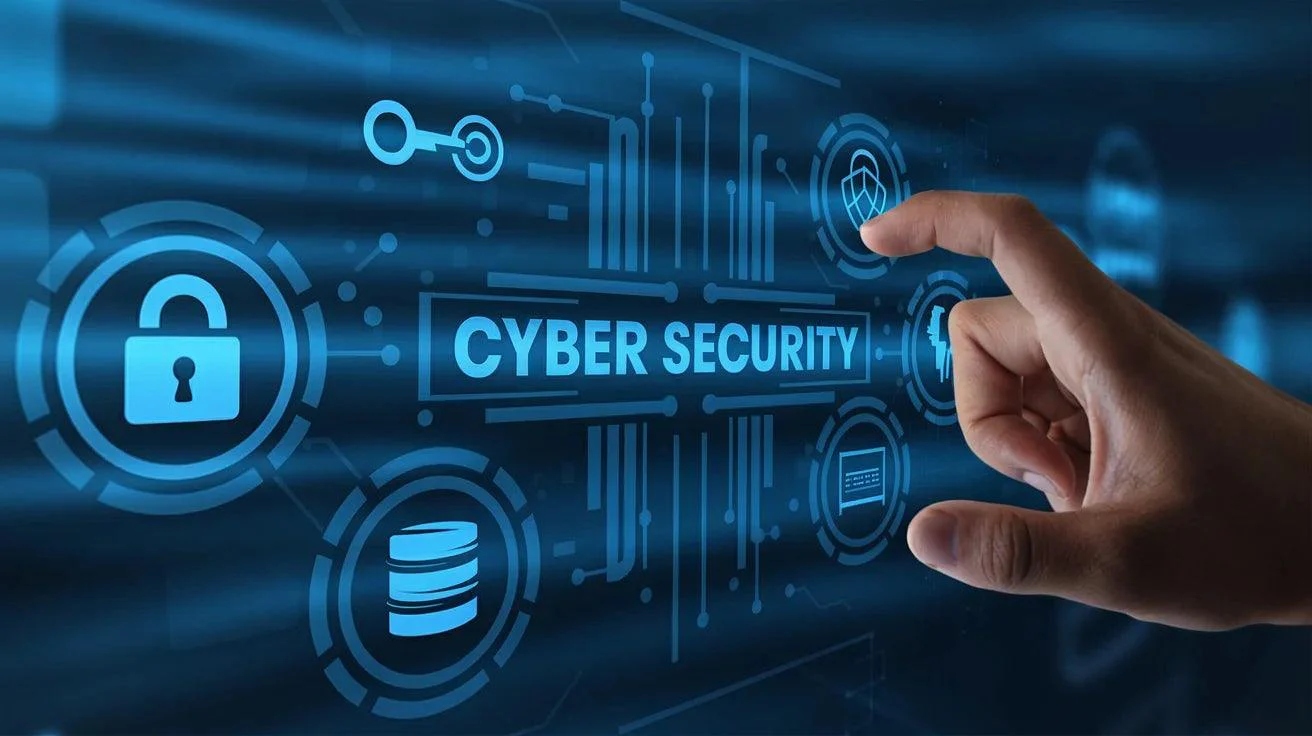

# **Cybersecurity Network Traffic Dataset: Baseline**

This dataset contains **network traffic records used for cybersecurity analysis**, specifically focused on detecting **Distributed Denial of Service (DDoS) and network flooding attacks**.  
Each CSV file represents traffic captured during a **specific attack type or normal network behavior**.


The dataset is divided into multiple CSV files, each corresponding to a specific attack category or normal traffic type.

| File | Description |
|-----|-------------|
| `DrDoS_DNS.csv` | DNS amplification Distributed Reflection Denial of Service attack traffic |
| `DrDoS_LDAP.csv` | LDAP reflection DDoS attack traffic |
| `DrDoS_MSSQL.csv` | MSSQL reflection DDoS attack traffic |
| `DrDoS_NetBIOS.csv` | NetBIOS reflection DDoS attack traffic |
| `DrDoS_NTP.csv` | NTP amplification attack traffic |
| `DrDoS_SNMP.csv` | SNMP reflection DDoS attack traffic |
| `DrDoS_SSDP.csv` | SSDP reflection DDoS attack traffic |
| `DrDoS_UDP.csv` | UDP flood distributed denial of service traffic |
| `Syn.csv` | SYN flood attack traffic |

These attack types are examples of volumetric or reflection-based DDoS attacks, where attackers overwhelm a server or network by generating massive traffic.

For training, we only consider the following CSV files due to limited computational resources. These CSV files were selected because these traffic types are commonly associated with reflection and amplification attacks. In these attacks, the attacker sends spoofed requests to legitimate servers (such as DNS, LDAP, or NTP services). The source IP address is forged to appear as the victim's address. As a result, the legitimate server sends the response to the victim instead of the attacker. Therefore, the analysis will focus on the following datasets:

- **DNS.csv**
- **LDAP.csv**
- **NTP.csv**
- **Syn.csv**



### **00 Libraries**

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns

### **01 Load Dataset**

The preprocessed dataset generated in the `02_Preprocessed.ipynb` notebook was loaded for the training phase.

After loading the dataset:

1. The target variable (`Label`) was separated from the feature set.
2. The label column was removed from the input features to avoid data leakage during training.
3. Feature scaling was applied using `StandardScaler`.

Standardization was performed to normalize the feature distributions and improve neural network convergence during training.

This preprocessing step ensures that all numerical features contribute proportionally during optimization and model training.

In [75]:
train_path = "preprocessed_data/train.csv"
val_path =  "preprocessed_data/val.csv"
test_path =  "preprocessed_data/test.csv"

In [76]:
train = pd.read_csv(train_path)
val = pd.read_csv(val_path)
test = pd.read_csv(test_path)

In [77]:
# Train
X_train = train.drop("Label", axis=1)
y_train = train["Label"]

# Validation
X_val = val.drop("Label", axis=1)
y_val = val["Label"]

# Test
X_test = test.drop("Label", axis=1)
y_test = test["Label"]

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# **1. Baseline Model**

A baseline neural network model was defined in order to establish a reference point for comparison with the Optuna multi-objective optimization process.

This baseline architecture was intentionally designed as a simple feedforward neural network with a fixed structure. The objective is to evaluate how much performance improvement can be achieved after hyperparameter optimization.

The model consists of:

- An input layer connected to:
  - A hidden layer with 32 neurons
  - A second hidden layer with 16 neurons
- A final output layer using a sigmoid activation function for binary classification

The sigmoid activation function was selected because the problem is formulated as a binary classification task, where the model predicts whether the network traffic corresponds to normal behavior or an attack.

The baseline architecture serves as the reference model against which the optimized Optuna-generated architectures are compared in terms of:

- F1-score
- Prediction time
- Overall classification performance






In [79]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [80]:
def create_baseline_model(input_dim):

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

## **Baseline Architecture**

| **Layer** | **Configuration** |
|---|---|
| Hidden Layer 1 | 32 neurons |
| Hidden Layer 2 | 16 neurons |
| Output Layer | 1 neuron + Sigmoid |

In [81]:
model = create_baseline_model(X_train.shape[1])
model.summary()

Model: "sequential_34"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_132 (Dense)           (None, 32)                2048      
                                                                 
 dense_133 (Dense)           (None, 16)                528       
                                                                 
 dense_134 (Dense)           (None, 1)                 17        
                                                                 
Total params: 2593 (10.13 KB)
Trainable params: 2593 (10.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [82]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    verbose=1
)

Epoch 1/20
98/98 [==============================] - 2s 6ms/step - loss: 0.2294 - accuracy: 0.9605 - auc: 0.9929 - val_loss: 0.0543 - val_accuracy: 0.9946 - val_auc: 0.9988
Epoch 2/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0285 - accuracy: 0.9967 - auc: 0.9995 - val_loss: 0.0253 - val_accuracy: 0.9973 - val_auc: 0.9993
Epoch 3/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0158 - accuracy: 0.9973 - auc: 0.9996 - val_loss: 0.0192 - val_accuracy: 0.9976 - val_auc: 0.9994
Epoch 4/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0122 - accuracy: 0.9976 - auc: 0.9996 - val_loss: 0.0154 - val_accuracy: 0.9976 - val_auc: 0.9994
Epoch 5/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0100 - accuracy: 0.9978 - auc: 0.9996 - val_loss: 0.0120 - val_accuracy: 0.9974 - val_auc: 0.9994
Epoch 6/20
98/98 [==============================] - 0s 3ms/step - loss: 0.0082 - accuracy: 0.9982 - auc: 0.9996 - val_loss: 0.0104 - val_acc

In [83]:
import time
import numpy as np

# -----------------------------
# Measure inference time
# -----------------------------

times = []

# Warmup
model.predict(
    X_test[:1],
    verbose=0
)

for _ in range(100):

    start = time.perf_counter()

    model.predict(
        X_test[:1],
        verbose=0
    )

    end = time.perf_counter()

    times.append(end - start)

# Average latency in milliseconds
baseline_inference_time_ms = float(
    np.mean(times) * 1000
)

# -----------------------------
# Predictions
# -----------------------------

y_pred_probs = model.predict(
    X_test,
    batch_size=4096,
    verbose=1
)

y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# -----------------------------
# Print result
# -----------------------------

print(
    f"Baseline Inference Time: "
    f"{baseline_inference_time_ms:.4f} ms/sample"
)

471/471 [==============================] - 1s 2ms/step
Baseline Inference Time: 62.3920 ms/sample


In [84]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy() )

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9991611786425092
Precision: 0.9999968804851469
Recall: 0.9991625895722661
F1 Score: 0.9995795609452135
AUC: 0.99972326

Confusion Matrix:
[[   3909       6]
 [   1612 1923370]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83      3915
           1       1.00      1.00      1.00   1924982

    accuracy                           1.00   1928897
   macro avg       0.85      1.00      0.91   1928897
weighted avg       1.00      1.00      1.00   1928897



In [85]:
import json

results = {

    "accuracy": float(
        accuracy_score(y_test, y_pred)
    ),

    "precision": float(
        precision_score(y_test, y_pred)
    ),

    "recall": float(
        recall_score(y_test, y_pred)
    ),

    "f1_score": float(
        f1_score(y_test, y_pred)
    ),

    "auc": float(
        tf.keras.metrics.AUC()(
            y_test,
            y_pred_probs
        ).numpy()
    ),

    "inference_time_ms": baseline_inference_time_ms,

    "confusion_matrix": confusion_matrix(
        y_test,
        y_pred
    ).tolist(),

    "classification_report": classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
}

# -----------------------------
# Save JSON
# -----------------------------

with open("evaluation_results_baseline.json", "w") as f:

    json.dump(
        results,
        f,
        indent=4
    )

print("Results exported to evaluation_results_baseline.json")

Results exported to evaluation_results_baseline.json


In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def confusion_matrix_heatmap(y_true, y_pred, save_path=None):
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Labels for your dataset
    labels = ["No Attack", "Attack"]

    # Create figure
    plt.figure(figsize=(6, 5), dpi=300)

    # Scientific-style heatmap
    ax = sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=True,
        square=True,
        linewidths=0.5,
        linecolor='gray',
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 12}
    )

    # Titles and labels
    plt.title("Confusion Matrix", fontsize=14, weight='bold')
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)

    # Improve tick appearance
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11, rotation=0)

    # Tight layout for publication
    plt.tight_layout()

    # Save high-quality figure if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

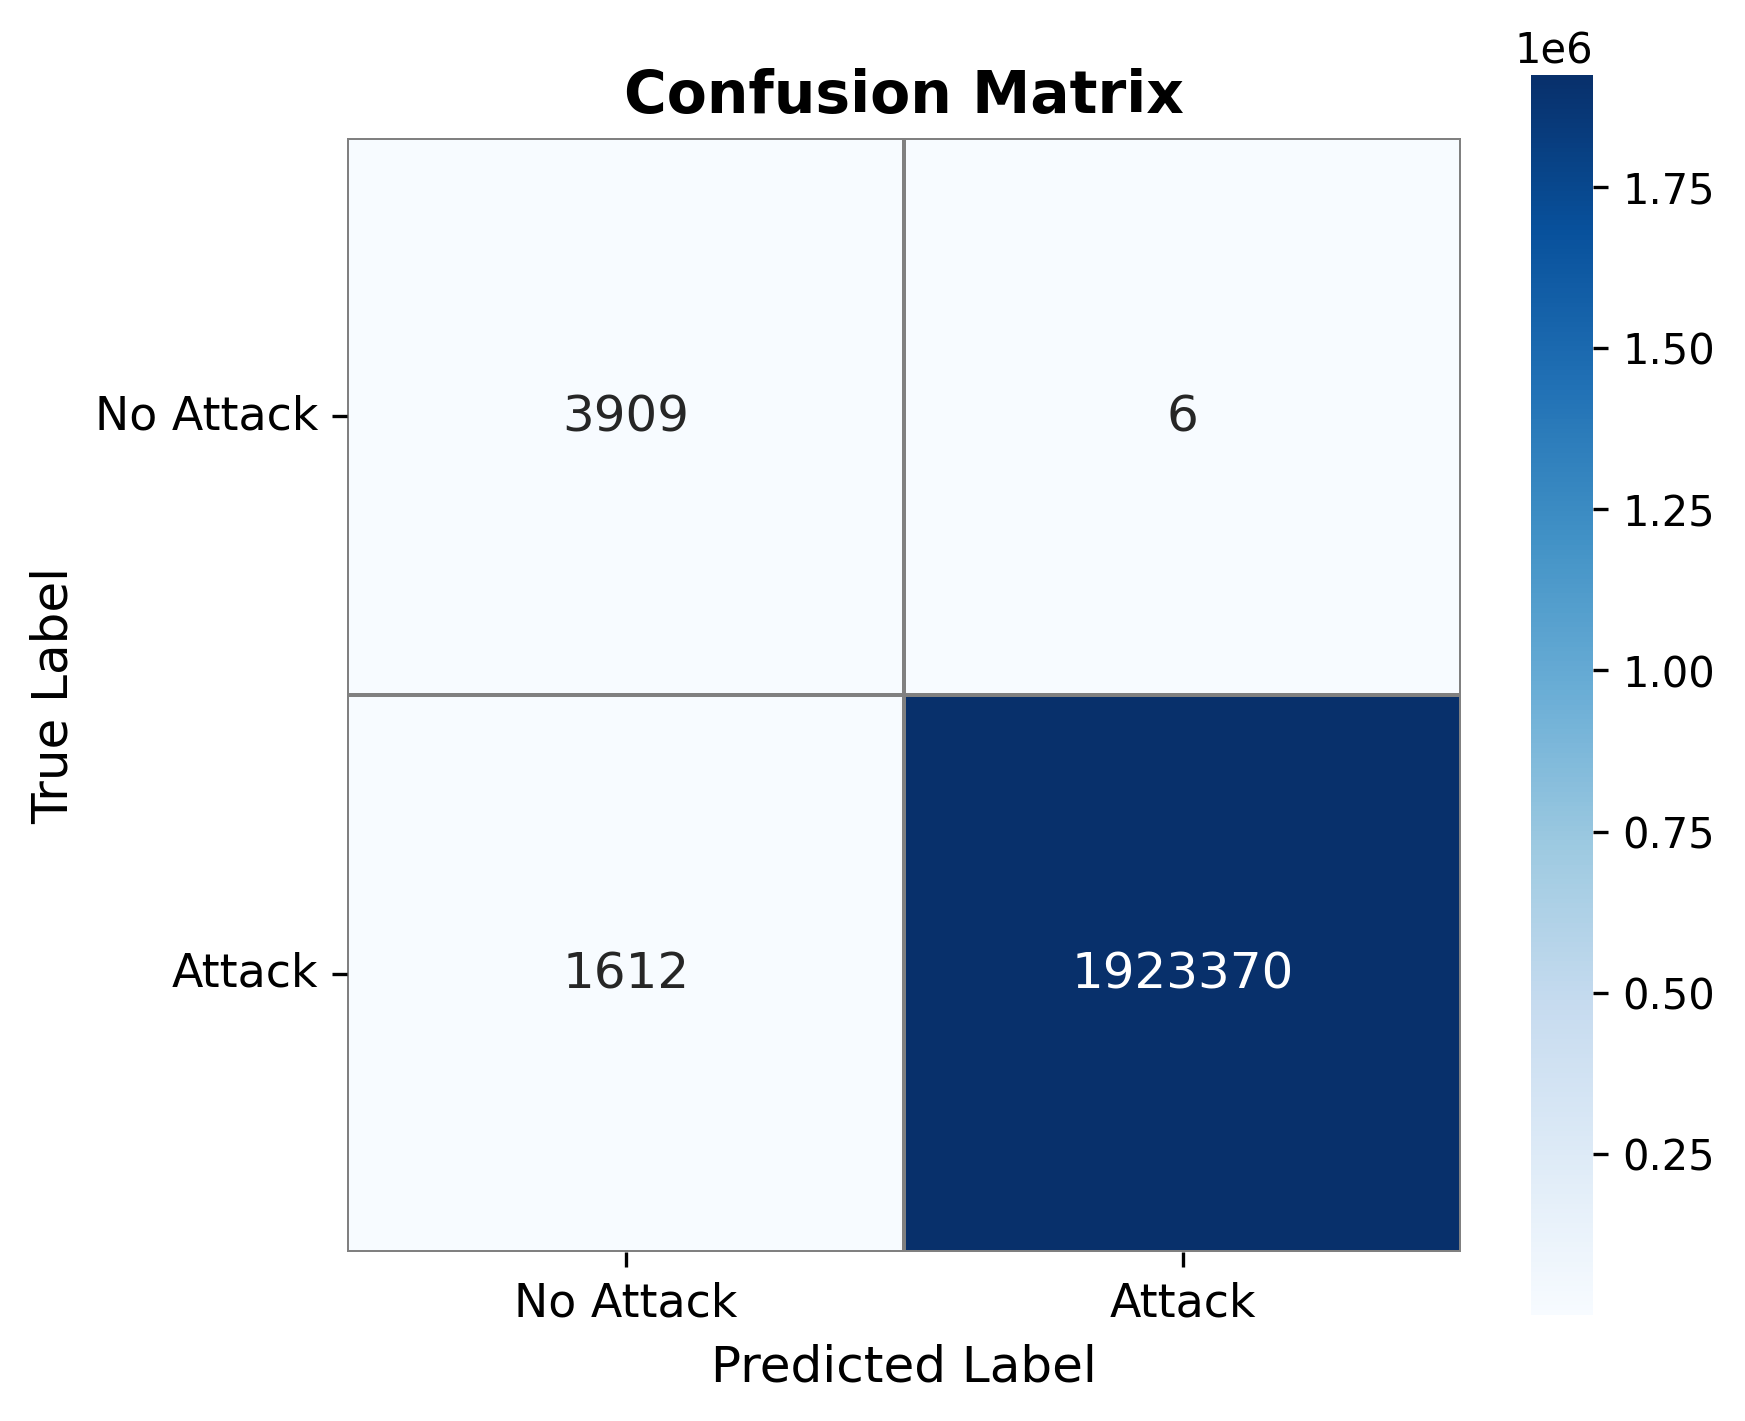

In [87]:
confusion_matrix_heatmap(y_test, y_pred)

# **2. Optuna**

In [88]:
import sys
!{sys.executable} -m pip install plotly


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
import sys
!{sys.executable} -m pip install optuna


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
import time
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [91]:
RANDOM_STATE = 42
N_TRIALS = 100
N_RUNS_TIMING = 10

# Hidden layer size range
HIDDEN_SIZE_MIN = 32
HIDDEN_SIZE_MAX = 256

# Number of hidden layers
NUM_LAYERS_MIN = 1
NUM_LAYERS_MAX = 5

# Learning rate range
LR_MIN = 1e-5
LR_MAX = 1e-2

# Batch size options
BATCH_SIZES = [32, 64, 128]

# Optimization directions
DIRECTIONS = ["maximize", "minimize"]

In [92]:
def build_model(hidden_size, lr, num_layers):

    model = keras.Sequential()

    # Input layer + first hidden layer
    model.add(
        layers.Dense(
            hidden_size,
            activation="relu",
            input_shape=(X_train.shape[1],)
        )
    )

    # Additional hidden layers
    current_size = hidden_size

    for _ in range(num_layers - 1):

        # Optional progressive reduction
        current_size = max(current_size // 2, 16)

        model.add(
            layers.Dense(
                current_size,
                activation="relu"
            )
        )

    # Output layer
    model.add(
        layers.Dense(1, activation="sigmoid")
    )

    # Optimizer
    optimizer = keras.optimizers.Adam(
        learning_rate=lr
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [93]:
def train_and_evaluate(model, batch_size):

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=batch_size,
        verbose=0
    )

    # Predictions
    y_pred = model.predict(X_val, verbose=0)

    # Convert probabilities to binary labels
    y_pred = (y_pred > 0.5).astype(int).flatten()

    # F1-score
    f1 = f1_score(y_val, y_pred)

    # Validation loss
    val_loss = history.history["val_loss"][-1]

    return val_loss, f1

In [94]:
import time
import numpy as np

def measure_inference_time(model, X_val, n_runs=N_RUNS_TIMING):

    # Single sample
    sample = X_val[:1]

    times = []

    # Warmup
    model.predict(sample, verbose=0)

    for _ in range(n_runs):

        start = time.perf_counter()

        model.predict(sample, verbose=0)

        end = time.perf_counter()

        times.append(end - start)

    return float(np.mean(times))

In [95]:
def objective(trial):

    # Hyperparameters
    hidden_size = trial.suggest_int(
        "hidden_size",
        HIDDEN_SIZE_MIN,
        HIDDEN_SIZE_MAX
    )

    num_layers = trial.suggest_int(
        "num_layers",
        NUM_LAYERS_MIN,
        NUM_LAYERS_MAX
    )

    lr = trial.suggest_float(
        "lr",
        LR_MIN,
        LR_MAX,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        BATCH_SIZES
    )

    # Build model
    model = build_model(
        hidden_size=hidden_size,
        lr=lr,
        num_layers=num_layers
    )

    # Train and evaluate
    val_loss, f1 = train_and_evaluate(
        model,
        batch_size
    )

    # Measure inference speed
    inference_time = measure_inference_time(
        model,
        X_val
    )

    # Multi-objective optimization
    return f1, inference_time

In [96]:
def create_study():

    study = optuna.create_study(
        directions=DIRECTIONS,
        sampler=optuna.samplers.NSGAIISampler(seed=RANDOM_STATE)
    )

    return study

In [97]:
import matplotlib.pyplot as plt

def print_pareto_front(study):

    pareto_trials = study.best_trials

    print(f"\nPareto-front trials: {len(pareto_trials)}")
    print("=" * 60)

    for t in pareto_trials:

        f1_score_val = t.values[0]
        inf_time_ms = t.values[1] * 1000

        print(
            f"Trial #{t.number:<3} | "
            f"F1-score: {f1_score_val:.4f} | "
            f"Inference Time: {inf_time_ms:.3f} ms"
        )

        print(f"Parameters: {t.params}")
        print("-" * 60)


def plot_pareto_front(study, save_path=None):

    pareto_trials = study.best_trials

    f1_scores = [t.values[0] for t in pareto_trials]

    inference_times = [
        t.values[1] * 1000
        for t in pareto_trials
    ]

    plt.figure(figsize=(7, 5), dpi=300)

    plt.scatter(
        inference_times,
        f1_scores,
        s=80,
        alpha=0.8
    )

    # Annotate each point with trial number
    for i, t in enumerate(pareto_trials):

        plt.annotate(
            f"T{t.number}",
            (inference_times[i], f1_scores[i]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    plt.xlabel("Inference Time (ms)", fontsize=12)
    plt.ylabel("F1-score", fontsize=12)

    plt.title(
        "Pareto Front for Multi-Objective Optimization",
        fontsize=14,
        weight='bold'
    )

    plt.grid(True)

    plt.tight_layout()

    # Save publication-quality figure
    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

In [98]:
study = create_study()

[I 2026-05-12 18:26:25,188] A new study created in memory with name: no-name-461b870c-8b78-40c0-b8a4-943f2fbb57f3


In [99]:
study.optimize(objective, n_trials=30)

[I 2026-05-12 18:26:40,512] Trial 0 finished with values: [0.9984051036682615, 0.06637385000212817] and parameters: {'hidden_size': 116, 'num_layers': 5, 'lr': 0.001570297088405539, 'batch_size': 32}.
[I 2026-05-12 18:26:45,469] Trial 1 finished with values: [0.9979249800478851, 0.05266365000134101] and parameters: {'hidden_size': 45, 'num_layers': 5, 'lr': 0.0006358358856676254, 'batch_size': 128}.
[I 2026-05-12 18:26:50,117] Trial 2 finished with values: [0.9976072738873824, 0.05667381999955978] and parameters: {'hidden_size': 219, 'num_layers': 2, 'lr': 3.511356313970405e-05, 'batch_size': 128}.
[I 2026-05-12 18:26:54,899] Trial 3 finished with values: [0.998404085541015, 0.06014617999899201] and parameters: {'hidden_size': 129, 'num_layers': 2, 'lr': 0.000684792009557478, 'batch_size': 128}.
[I 2026-05-12 18:27:03,056] Trial 4 finished with values: [0.9982447742141376, 0.06204749999888008] and parameters: {'hidden_size': 134, 'num_layers': 4, 'lr': 3.972110727381908e-05, 'batch_siz

In [100]:
print_pareto_front(study)


Pareto-front trials: 3
Trial #7   | F1-score: 0.9981 | Inference Time: 48.516 ms
Parameters: {'hidden_size': 39, 'num_layers': 5, 'lr': 5.9750279999602906e-05, 'batch_size': 32}
------------------------------------------------------------
Trial #20  | F1-score: 0.9982 | Inference Time: 53.067 ms
Parameters: {'hidden_size': 213, 'num_layers': 5, 'lr': 8.995191735587162e-05, 'batch_size': 128}
------------------------------------------------------------
Trial #23  | F1-score: 0.9992 | Inference Time: 53.395 ms
Parameters: {'hidden_size': 113, 'num_layers': 5, 'lr': 0.007715105777813051, 'batch_size': 64}
------------------------------------------------------------


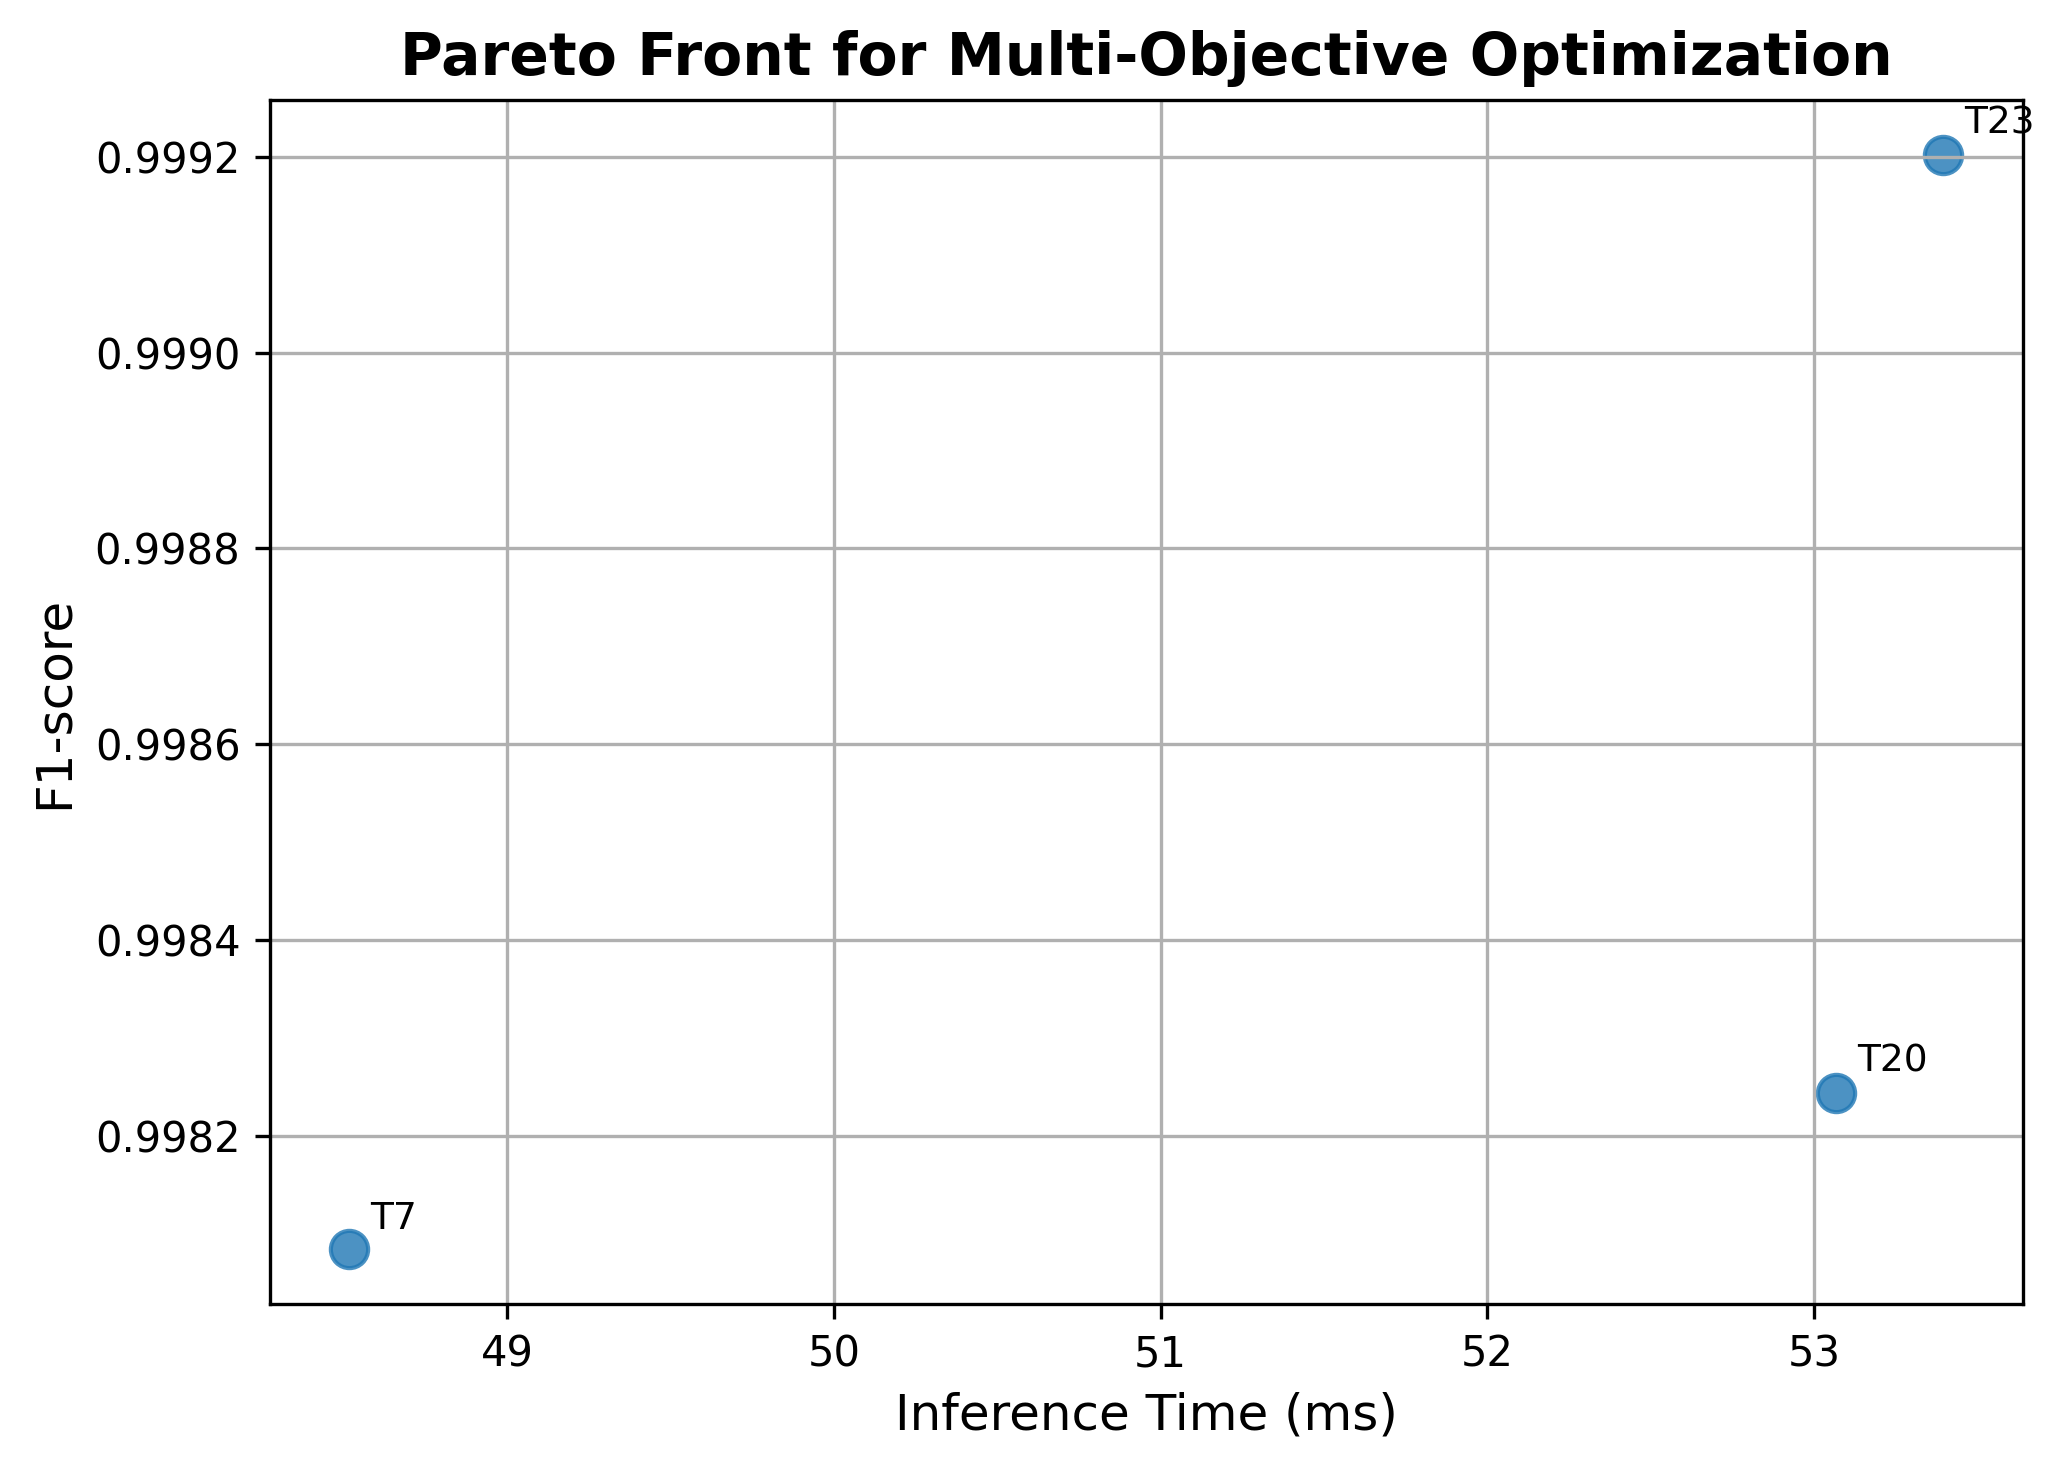

In [101]:
plot_pareto_front(study)

In [102]:
import pandas as pd

def pareto_dataframe(study):

    rows = []

    for t in study.best_trials:

        rows.append({
            "Trial": t.number,
            "F1-score": round(t.values[0], 4),
            "Inference Time (ms)": round(t.values[1] * 1000, 3),
            "Hidden Size": t.params["hidden_size"],
            "Num Layers": t.params["num_layers"],
            "Learning Rate": t.params["lr"],
            "Batch Size": t.params["batch_size"]
        })

    df = pd.DataFrame(rows)

    return df

In [103]:
df_pareto = pareto_dataframe(study)

print(df_pareto)

   Trial  F1-score  Inference Time (ms)  Hidden Size  Num Layers  \
0      7    0.9981               48.516           39           5   
1     20    0.9982               53.067          213           5   
2     23    0.9992               53.395          113           5   

   Learning Rate  Batch Size  
0       0.000060          32  
1       0.000090         128  
2       0.007715          64  


In [104]:
df_pareto.to_csv("pareto_results.csv", index=False)

In [105]:
best_trial = df_pareto.iloc[1]

# **4.Train Best Model**

In [106]:
best_params = best_trial

final_model = build_model(
    hidden_size=int(best_params["Hidden Size"]),
    lr=float(best_params["Learning Rate"]),
    num_layers=int(best_params["Num Layers"])
)

history = final_model.fit(
    X_train,
    y_train,
    batch_size=int(best_params["Batch Size"]),
    epochs=20,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
196/196 [==============================] - 2s 3ms/step - loss: 0.3858 - accuracy: 0.9007 - val_loss: 0.0976 - val_accuracy: 0.9958
Epoch 2/20
196/196 [==============================] - 0s 2ms/step - loss: 0.0368 - accuracy: 0.9970 - val_loss: 0.0191 - val_accuracy: 0.9966
Epoch 3/20
196/196 [==============================] - 0s 2ms/step - loss: 0.0124 - accuracy: 0.9977 - val_loss: 0.0123 - val_accuracy: 0.9973
Epoch 4/20
196/196 [==============================] - 0s 2ms/step - loss: 0.0087 - accuracy: 0.9980 - val_loss: 0.0102 - val_accuracy: 0.9981
Epoch 5/20
196/196 [==============================] - 0s 2ms/step - loss: 0.0072 - accuracy: 0.9984 - val_loss: 0.0093 - val_accuracy: 0.9981
Epoch 6/20
196/196 [==============================] - 0s 2ms/step - loss: 0.0065 - accuracy: 0.9986 - val_loss: 0.0088 - val_accuracy: 0.9981
Epoch 7/20
196/196 [==============================] - 0s 2ms/step - loss: 0.0060 - accuracy: 0.9986 - val_loss: 0.0082 - val_accuracy: 0.9981
Epoch 

In [107]:
# Predictions
y_pred = final_model.predict(X_test, verbose=0)
y_pred = (y_pred > 0.5).astype(int).flatten()

# F1-score
test_f1 = f1_score(y_test, y_pred)

# -----------------------------
# Measure inference latency
# -----------------------------

sample = X_test[:1]

times = []

# Warmup
final_model.predict(sample, verbose=0)

for _ in range(100):

    start = time.perf_counter()

    final_model.predict(sample, verbose=0)

    end = time.perf_counter()

    times.append(end - start)

# Average latency in milliseconds
avg_inference_time_ms = np.mean(times) * 1000

# Results
print(f"Test F1-score: {test_f1:.4f}")

print(
    f"Average Inference Time: "
    f"{avg_inference_time_ms:.4f} ms/sample"
)

Test F1-score: 0.9997
Average Inference Time: 62.8564 ms/sample


In [108]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy() )

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.999350924388394
Precision: 0.9999968810786478
Recall: 0.9993527212202503
F1 Score: 0.9996746973802226
AUC: 0.99972326

Confusion Matrix:
[[   3909       6]
 [   1246 1923736]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.86      3915
           1       1.00      1.00      1.00   1924982

    accuracy                           1.00   1928897
   macro avg       0.88      1.00      0.93   1928897
weighted avg       1.00      1.00      1.00   1928897



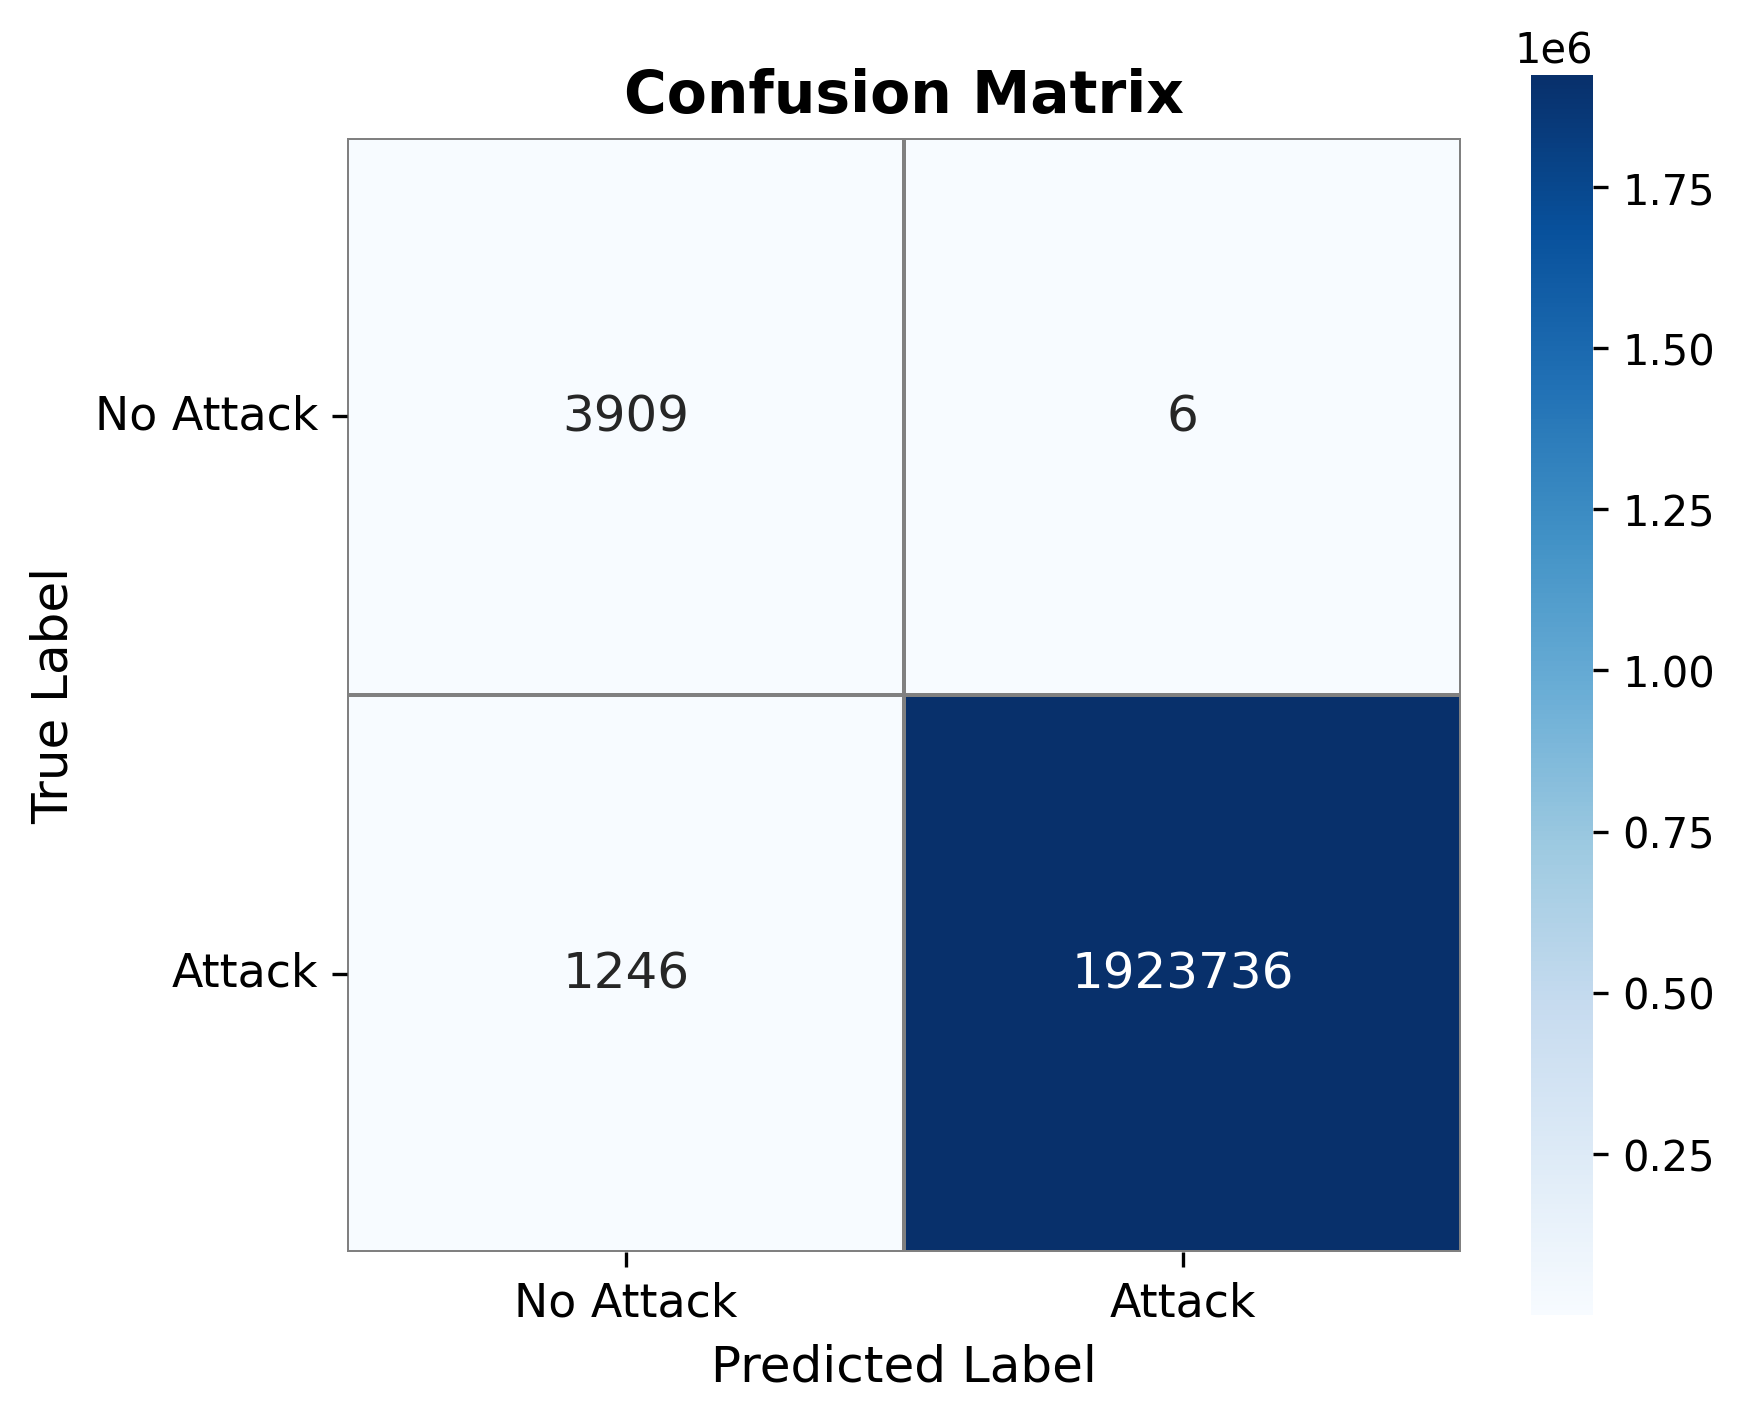

In [109]:
confusion_matrix_heatmap(y_test, y_pred)

In [110]:
import json
# -----------------------------
# Metrics
# -----------------------------

results = {

    "accuracy": float(
        accuracy_score(y_test, y_pred)
    ),

    "precision": float(
        precision_score(y_test, y_pred)
    ),

    "recall": float(
        recall_score(y_test, y_pred)
    ),

    "f1_score": float(
        f1_score(y_test, y_pred)
    ),

    "auc": float(
        tf.keras.metrics.AUC()(
            y_test,
            y_pred_probs
        ).numpy()
    ),

    "inference_time_ms": avg_inference_time_ms,

    "confusion_matrix": confusion_matrix(
        y_test,
        y_pred
    ).tolist(),

    "classification_report": classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
}

# -----------------------------
# Save JSON
# -----------------------------

with open("evaluation_results_optuna.json", "w") as f:

    json.dump(
        results,
        f,
        indent=4
    )

print("Results exported to evaluation_results_optuna.json")

Results exported to evaluation_results_optuna.json
